# Analise Venda

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura de Dados

In [ ]:
df = pd.read_excel("dados_vendas_brutos_corrigidos.xlsx", engine="openpyxl")

Visualização dos Dados

In [ ]:
display(df.sample(10))
display(df.info())
display(df.dtypes)
display(df.isnull().sum())

Limpeza e Análise das Datas

In [ ]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["nome_mes"] = df["data"].dt.month_name(locale="pt_BR")
df["nome_dia"] = df["data"].dt.day_name(locale="pt_BR")
df["mes_ano"] = df["data"].dt.to_period("M")

Enriquecimento da Coluna Valor Venda

In [ ]:
df["valor_venda"] = df["quantidade"] * df["preco_unitario"]

Gráfico Produto Venda

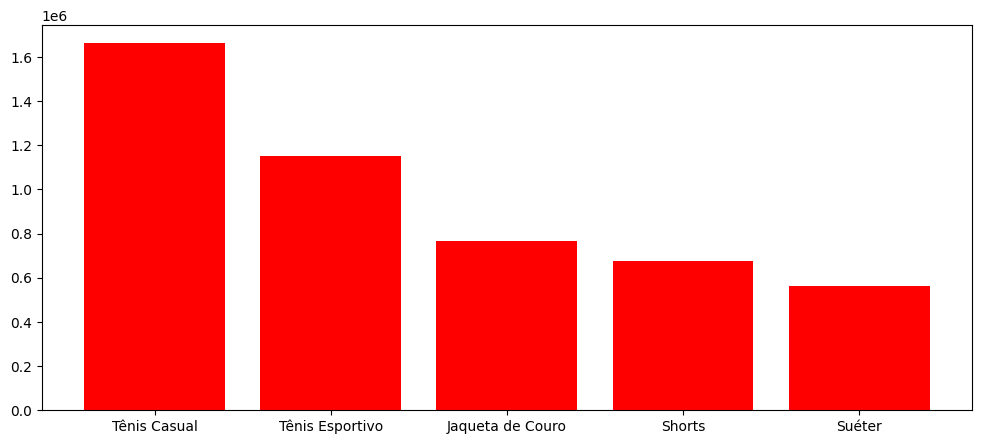

In [ ]:
produto_venda = df.groupby("produto").agg(
    total_venda=("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=False)

plt.figure(figsize=(12,5))

plt.bar(produto_venda["produto"], produto_venda["total_venda"], color="red")
plt.show()

Gráfico de Barras Faturamento por Loja

In [ ]:
faturamento_loja = df.groupby("loja").agg(
    total_venda = ("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=True)


cores = plt.cm.tab10(range(len(faturamento_loja["loja"])))

plt.figure(figsize=(15,5))

barras = plt.bar(faturamento_loja["loja"], faturamento_loja["total_venda"], color = cores)

plt.title("Loja X Faturamento")

plt.xlabel("Lojas")
plt.ylabel("Faturamento")

plt.grid(True, axis="y", alpha=0.3)


for bar in barras:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"R$ {bar.get_height():.2f}",
        ha="center",
        va="bottom"

    )


plt.show()